In [1]:
# Import pandas - a library that lets us work with tables of data
import pandas as pd

# Load the insurance dataset from the internet into a table called 'insurance'
insurance = pd.read_csv('https://raw.githubusercontent.com/KeithGalli/Regression-Example/master/insurance.csv')

In [2]:
# Show the first 5 rows of the dataset so we can see what it looks like
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.924
1,18.0,male,33.770,1.0,no,Southeast,1725.5523
2,28.0,male,33.000,3.0,no,southeast,$4449.462
3,33.0,male,22.705,0.0,no,northwest,$21984.47061
4,32.0,male,28.880,0.0,no,northwest,$3866.8552


In [3]:
# ---- STEP 1: DATA CLEANING ----
# Goal: fix messy data so it's consistent and ready for analysis

# Remove any rows that have missing (empty) values
insurance_filled = insurance.dropna()

# Make all region names lowercase so 'Southwest' and 'southwest' are treated the same
insurance_filled["region"] = insurance_filled["region"].str.lower()

# Map any alternate sex labels to standard 'male' / 'female'
# (in case the data had values like 'M', 'F', 'man', 'woman')
sex_map = {'woman': 'female', 'F': 'female', 'man': 'male', 'M': 'male'}
insurance_filled["sex"] = insurance_filled["sex"].replace(sex_map)

# Convert smoker column from 'yes'/'no' text to True/False (boolean)
insurance_filled["smoker"] = (insurance_filled["smoker"] == 'yes')

# Make all number columns positive (remove any accidental negative values)
# Skips text columns automatically
insurance_filled["charges"] = insurance_filled["charges"].str.strip('$').astype('float64')
insurance_cleaned = insurance_filled.apply(lambda x: x.abs() if x.dtype == 'float64' or x.dtype == 'int64' else x)

# Drop any rows that might still have missing values after cleaning
insurance_cleaned = insurance_cleaned.dropna()

# Save the cleaned data to a CSV file so we don't have to redo this every time
insurance_cleaned.to_csv('cleaned_insurance_data.csv', index=False)

# Show a random sample of 10 rows to confirm the data looks good
insurance_cleaned.sample(10)

,age,sex,bmi,children,smoker,region,charges
31,18.0,female,26.315,0.0,False,northeast,2198.18985
1122,53.0,female,36.860,3.0,True,northwest,46661.44240
403,49.0,male,32.300,3.0,False,northwest,10269.46000
924,43.0,male,23.200,0.0,False,southwest,6250.43500
1096,51.0,female,34.960,2.0,True,northeast,44641.19740
578,52.0,male,30.200,1.0,False,southwest,9724.53000
856,48.0,female,33.110,0.0,True,southeast,40974.16490
1100,33.0,female,19.095,2.0,True,northeast,16776.30405
125,26.0,female,28.785,0.0,False,northeast,3385.39915
1086,55.0,male,28.975,0.0,False,northeast,10796.35025


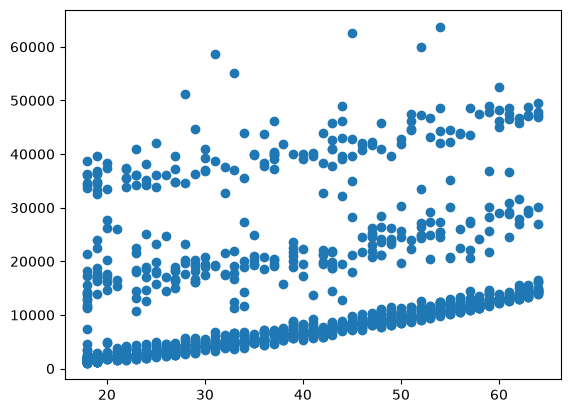

In [4]:
#2. Create a plot of the data

# Import pyplot - the tool inside matplotlib used to draw charts
import matplotlib.pyplot as plt

# Make a copy of the cleaned data so we don't accidentally change the original
df = insurance_cleaned.copy()

# Show Y-axis numbers as plain values (e.g. 10000) instead of weird scientific format (e.g. 1e4)
plt.ticklabel_format(style='plain', axis='y')

# Draw a scatter plot: each dot = one person, X = their age, Y = their insurance charge
plt.scatter(df['age'], df['charges'])

# Display the plot
plt.show()

In [5]:
#3. Converting all the string (text) columns into numbers so the ML model can understand them

# Make a copy of the dataframe so we keep the original safe
df_new = df.copy()

# 'region' has 4 values (southwest, southeast, northwest, northeast)
# get_dummies splits it into 4 columns, each with 1 (yes) or 0 (no)
df_new = pd.get_dummies(df, columns=['region'], dtype=int)

# Convert smoker column from True/False to 1/0
df_new["smoker"] = df_new["smoker"].astype('int64')

# Create a new column 'is_male': 1 if the person is male, 0 if female
df_new["is_male"] = (df_new["sex"] == 'male')

# Convert is_male from True/False to 1/0 so it's a proper number like the other columns
df_new["is_male"] = df_new["is_male"].astype('int64')

# Remove the original 'sex' column since we replaced it with 'is_male'
df_new = df_new.drop(columns=["sex"])

# Show the first 5 rows to confirm everything looks correct
df_new.head()

,age,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,is_male
0,19.0,27.900,0.0,1,16884.92400,0,0,0,1,0
1,18.0,33.770,1.0,0,1725.55230,0,0,1,0,1
2,28.0,33.000,3.0,0,4449.46200,0,0,1,0,1
3,33.0,22.705,0.0,0,21984.47061,0,1,0,0,1
4,32.0,28.880,0.0,0,3866.85520,0,1,0,0,1


In [6]:
# ---- STEP 4: TRAIN A LINEAR REGRESSION MODEL ----
# Goal: teach the computer to predict insurance charges based on a person's details

# Import the tools we need from scikit-learn (a machine learning library)
from sklearn.linear_model import LinearRegression   # The model we'll use
from sklearn.model_selection import train_test_split # To split data into train & test
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # To check how good the model is

# ------ SPLIT DATA INTO INPUTS (X) AND ANSWER (y) ------
# X = everything the model will use to make predictions (age, bmi, smoker, etc.)
# y = the thing we want to predict (charges)
X = df_new.drop(columns=['charges'])  # X = all columns EXCEPT charges
y = df_new['charges']                 # y = only the charges column

# ------ SPLIT INTO TRAINING DATA AND TESTING DATA ------
# We train the model on 80% of the data
# We test (evaluate) it on the remaining 20% it has never seen before
# random_state=42 just means the split will be the same every time we run this
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ------ TRAIN (FIT) THE MODEL ------
# Create a blank Linear Regression model
model = LinearRegression()

# Feed the training data to the model so it can learn the patterns
# After this line, the model knows: 'higher age usually means higher charges', etc.
model.fit(X_train, y_train)

# ------ MAKE PREDICTIONS ------
# Ask the trained model to predict charges for the 20% test data
# These are people the model has never seen — a fair test!
y_pred = model.predict(X_test)

# ------ CHECK HOW ACCURATE THE MODEL IS ------
# MAE  = on average, how many dollars off is each prediction?
#        e.g. MAE of $4000 means predictions are off by ~$4000 on average
mae = mean_absolute_error(y_test, y_pred)

# MSE  = same idea but BIG errors are penalised more heavily
#        useful to detect if there are some very bad predictions
mse = mean_squared_error(y_test, y_pred)

# R2   = how much of the variation in charges does our model explain?
#        1.0 = perfect predictions, 0.0 = model is no better than guessing the average
r2  = r2_score(y_test, y_pred)

# Print the results in a clean, readable format
print(f'Mean Absolute Error  (MAE) : ${mae:,.2f}')
print(f'Mean Squared Error   (MSE) : ${mse:,.2f}')
print(f'R² Score               : {r2:.4f}')

Mean Absolute Error  (MAE) : $4,378.72
Mean Squared Error   (MSE) : $39,936,613.36
R² Score               : 0.7049
